In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from itertools import product
import matplotlib.pyplot as plt
from metrics import compute_metrics, compute_ss 
from ensemble import compute_ensemble

import matplotlib as mpl 
# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12


Load data 

In [2]:
data = pd.read_csv('predictions/dengue_agg.csv.gz')
data.date = pd.to_datetime(data.date)
#data = data.groupby(['date', 'uf'])[['casos']].sum().reset_index()
#data = data.sort_values(by = 'date')
data.head()

,date,casos,uf
0,2010-01-03,73.0,AL
1,2010-01-10,98.0,AL
2,2010-01-17,146.0,AL
3,2010-01-24,162.0,AL
4,2010-01-31,245.0,AL


Load the predictions: 

In [3]:
df_preds = pd.read_csv('predictions/preds_2nd_sprint_update.csv.gz')

df_preds = df_preds.loc[~df_preds.model_id.isin([137, 138,141])]
df_preds['date'] = pd.to_datetime(df_preds.date)

df_preds['valid_test'] = df_preds['valid_test'].astype(str)

df_preds = df_preds.loc[df_preds.valid_test.isin(['1', '2', '3'])]

df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,valid_test,state,model_id
0,2024-10-06,38.773291,47.763807,60.738967,90.734958,141.694291,221.242326,330.372751,419.958960,517.109128,3,PA,108
1,2024-10-13,45.109840,55.739146,71.131107,106.889566,168.026644,264.099302,396.728996,506.114194,625.130454,3,PA,108
2,2024-10-20,41.814331,51.824573,66.367288,100.313705,158.710997,251.070224,379.348800,485.622490,601.625766,3,PA,108
3,2024-10-27,56.360496,70.048836,89.997844,136.779116,217.737829,346.580496,526.586520,676.366250,840.369406,3,PA,108
4,2024-11-03,62.131360,77.438292,99.814751,152.524496,244.274360,391.179445,597.597813,770.084987,959.525955,3,PA,108


In [4]:
df_preds.model_id.unique().shape

(15,)

Load the metrics computed using the WIS normalized:

In [5]:
df_m_norm = pd.read_csv('results/metrics_wis_norm.csv.gz')

df_m_norm.head()

,model,state,validation_test,WIS
0,108,PA,1,0.306515
1,158,PA,1,0.235720
2,133,PA,1,0.178181
3,144,PA,1,0.162322
4,152,PA,1,0.628968


In [6]:
df_m_norm.loc[(df_m_norm.model == 108) & (df_m_norm.state == 'PA')]

,model,state,validation_test,WIS
0,108,PA,1,0.306515
15,108,PA,2,0.355363
30,108,PA,3,0.450550


In [7]:
df_m_norm.model.unique()

array([108, 158, 133, 144, 152, 157, 134, 150, 143, 154, 145, 156, 135,
       136, 155])

Get the median ensemble of all models:

In [8]:
df_median_ens = compute_ensemble(df_preds)
df_median_ens['model_id'] = 'E_median_all'
df_median_ens.head()

,date,state,valid_test,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id
0,2022-10-09,AC,1,4.000000,6.000000,11.000000,23.000000,48.000000,99.000000,178.000000,268.100000,397.050000,E_median_all
1,2022-10-09,AL,1,20.220144,30.000000,38.000000,63.000000,148.202649,240.000000,387.533109,425.000000,475.020233,E_median_all
2,2022-10-09,AM,1,9.466215,12.658231,16.995048,28.000000,48.000000,78.000000,134.000000,176.000000,222.000000,E_median_all
3,2022-10-09,AP,1,0.000000,0.221357,1.000000,2.477594,4.792211,10.131715,17.797631,24.642042,37.000000,E_median_all
4,2022-10-09,BA,1,33.000000,45.000000,64.000000,86.114546,164.000000,242.708848,352.169266,461.022765,622.212427,E_median_all


Get the best model for state based on the mean of validation test 1 and 2.

In [9]:
df_m_v12 = df_m_norm.loc[df_m_norm.validation_test.isin([1, 2])].groupby(['model', 'state'])[['WIS']].mean().reset_index()

df_m_v12 = df_m_v12.loc[df_m_v12.groupby("state")["WIS"].idxmin()][['model', 'state']].rename(columns = {'model':'best_model_norm'})

df_m_v12.head()

,best_model_norm,state
27,133,AC
80,135,AL
160,144,AM
3,108,AP
109,136,BA


Get the wis of this models in validation test 3:

In [10]:
df_bm_v3_wis = df_m_v12.merge(df_m_norm.loc[df_m_norm.validation_test ==3],
               left_on = ['best_model_norm', 'state'],
               right_on = ['model', 'state'])
df_bm_v3_wis['validation_test'] = df_bm_v3_wis['validation_test'].astype(str)
df_bm_v3_wis.head()

,best_model_norm,state,model,validation_test,WIS
0,133,AC,133,3,0.283760
1,135,AL,135,3,0.341129
2,144,AM,144,3,0.159181
3,108,AP,108,3,4.862754
4,136,BA,136,3,0.257562


Compute the WIS of the ensemble models

In [11]:
df_m_ens = pd.DataFrame()

for state, test_year in product(df_median_ens.state.unique(), ['1', '2', '3']):
    #print(f'{state} - {test_year}')
    df_preds_ = df_median_ens.loc[(df_median_ens.state == state) & (df_median_ens.valid_test == test_year)].sort_values(by='date')

    df_w = data.loc[(data.uf == state) & data.date.isin(df_preds_.date.unique())].reset_index(drop=True)

    scores =[]
    models_ids = df_preds_.model_id.unique()
    
    for model in models_ids: 
        #print(model)
    
        wis = compute_metrics(model, df_w, df_preds_)
        
        df_m_ens = pd.concat([df_m_ens,
                           pd.DataFrame([[model, state, test_year, wis ]],
                            columns = ['model', 'state', 'validation_test', 'WIS'] 
                            )], ignore_index = True)

df_m_ens.head()

,model,state,validation_test,WIS
0,E_median_all,AC,1,0.319872
1,E_median_all,AC,2,0.370746
2,E_median_all,AC,3,0.232481
3,E_median_all,AL,1,0.585141
4,E_median_all,AL,2,0.230046


merged with the best model wis:

In [12]:
df_m_merged = df_bm_v3_wis.merge(df_m_ens, on = ['state', 'validation_test'], suffixes=('', '_ens'))

df_m_merged.head()

,best_model_norm,state,model,validation_test,WIS,model_ens,WIS_ens
0,133,AC,133,3,0.283760,E_median_all,0.232481
1,135,AL,135,3,0.341129,E_median_all,0.429003
2,144,AM,144,3,0.159181,E_median_all,0.234123
3,108,AP,108,3,4.862754,E_median_all,0.249132
4,136,BA,136,3,0.257562,E_median_all,0.284538


compute the ss between the ensemble and the model in the validation test 3

In [13]:
df_m_merged['SS'] = compute_ss(df_m_merged, col1 = 'WIS_ens', col_ref = 'WIS')

df_m_merged.head()

,best_model_norm,state,model,validation_test,WIS,model_ens,WIS_ens,SS
0,133,AC,133,3,0.283760,E_median_all,0.232481,0.180712
1,135,AL,135,3,0.341129,E_median_all,0.429003,-0.257595
2,144,AM,144,3,0.159181,E_median_all,0.234123,-0.470797
3,108,AP,108,3,4.862754,E_median_all,0.249132,0.948767
4,136,BA,136,3,0.257562,E_median_all,0.284538,-0.104737


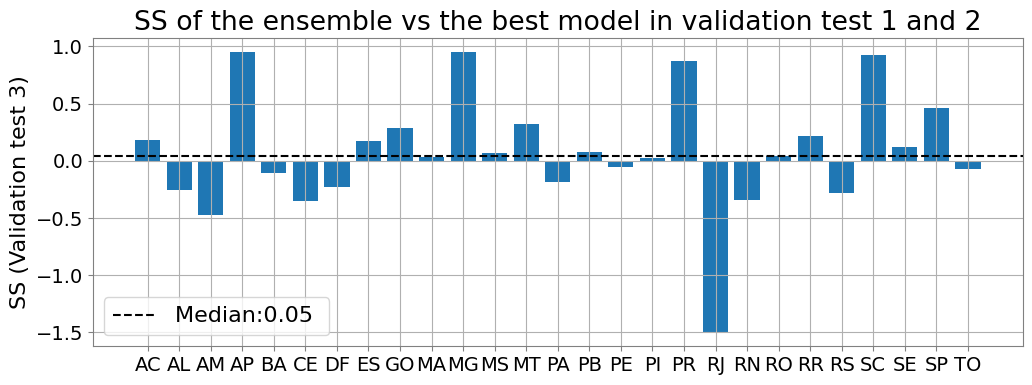

In [14]:
_,ax = plt.subplots(figsize = (12, 4))

ax.bar(df_m_merged.state, df_m_merged.SS)

ax.axhline(np.median(df_m_merged.SS), color = 'black', 
              linestyle = '--', label = f'Median:{np.round(np.median(df_m_merged.SS),2)} ')

ax.grid()
ax.legend()
ax.set_ylabel('SS (Validation test 3)')
ax.set_title('SS of the ensemble vs the best model in validation test 1 and 2')
plt.show()

Compare with the individual models in all the validation tests: 

In [15]:
df_m_ens.validation_test.unique()

array(['1', '2', '3'], dtype=object)

In [16]:
df_m_norm.validation_test.unique()

array([1, 2, 3])

In [17]:
order = [
    # Sul
    'PR', 'RS', 'SC',
    # Sudeste
    'ES', 'MG', 'RJ', 'SP',
    # Centro-Oeste
    'DF', 'GO', 'MT', 'MS',
    # Nordeste
    'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE',
    # Norte
    'AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO' ]



In [18]:
df_ss_median_all = pd.DataFrame()

for state, val_test in product(df_m_norm.state.unique(), ['1', '2', '3']):
    
    dfm = df_m_norm.loc[(df_m_norm.state == state ) & (df_m_norm.validation_test == int(val_test))]

    dfm_e = df_m_ens.loc[(df_m_ens.validation_test == val_test) & (df_m_ens.state == state)]
    
    for model in dfm.model.unique(): 

        ss =  1- (dfm_e.WIS.values[0]/dfm.loc[dfm.model == model].WIS.values[0])

        df_ss_median_all = pd.concat([df_ss_median_all,
                           pd.DataFrame([[state, val_test, model, ss ]],
                            columns = ['state', 'val_test', 'model_ref', 'SS'] 
                            )], ignore_index = True)

df_ss_median_all['state'] = pd.Categorical(df_ss_median_all['state'],
                                     categories = order,
                                     ordered = True)

df_ss_median_all['above_zero'] = True
df_ss_median_all.loc[df_ss_median_all.SS <= 0, 'above_zero'] = False

df_ss_median_all.head()

,state,val_test,model_ref,SS,above_zero
0,PA,1,108,0.368788,True
1,PA,1,158,0.179212,True
2,PA,1,133,-0.085842,False
3,PA,1,144,-0.191927,False
4,PA,1,152,0.692391,True


In [19]:
df_ss_median_all.val_test.unique()

array(['1', '2', '3'], dtype=object)

In [20]:
df_ssm1 = df_ss_median_all.loc[df_ss_median_all.val_test == '1']

df_ssm1['model_ref']  = df_ssm1['model_ref'].replace(
    { 133:'Chronos-Bolt\n(AL, CE, PB, RR)',
     135:'GHR Model\n(RN)',
    157: 'UERJ-SARIMAX-2 (SC)'})

df_ssm2 = df_ss_median_all.loc[df_ss_median_all.val_test == '2']

df_ssm2['model_ref']  = df_ssm2['model_ref'].replace(
    {108:'IMPA-TECH\n(MG, SP)', 
     136: 'Imperial-TFT Model (GO)',
     156: 'Dengue oracle M2\n(MT)',
     135:'GHR Model\n(GO)', 
     152: 'LNCC-CLIDENGO-1 (AP)',
    133:'Chronos-Bolt\n(CE)',
    157: 'UERJ-SARIMAX-2 (SC)'})

df_ssm3 = df_ss_median_all.loc[df_ss_median_all.val_test == '3']

df_ssm3['model_ref']  = df_ssm3['model_ref'].replace(
    {145: 'CNNLSTM \n(SC)',
     156: 'Dengue oracle M2\n(RJ)',
     150: 'LNCC-AR_p-1\n(MS)'})


/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_9653/3916716297.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ssm1['model_ref']  = df_ssm1['model_ref'].replace(
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_9653/3916716297.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ssm2['model_ref']  = df_ssm2['model_ref'].replace(
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_9653/3916716297.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [21]:
df_ssm3.loc[df_ssm3.SS <= -1]

,state,val_test,model_ref,SS,above_zero
266,RJ,3,Dengue oracle M2\n(RJ),-1.499455,False
577,MS,3,LNCC-AR_p-1\n(MS),-1.012529,False
1108,SC,3,CNNLSTM \n(SC),-2.958735,False


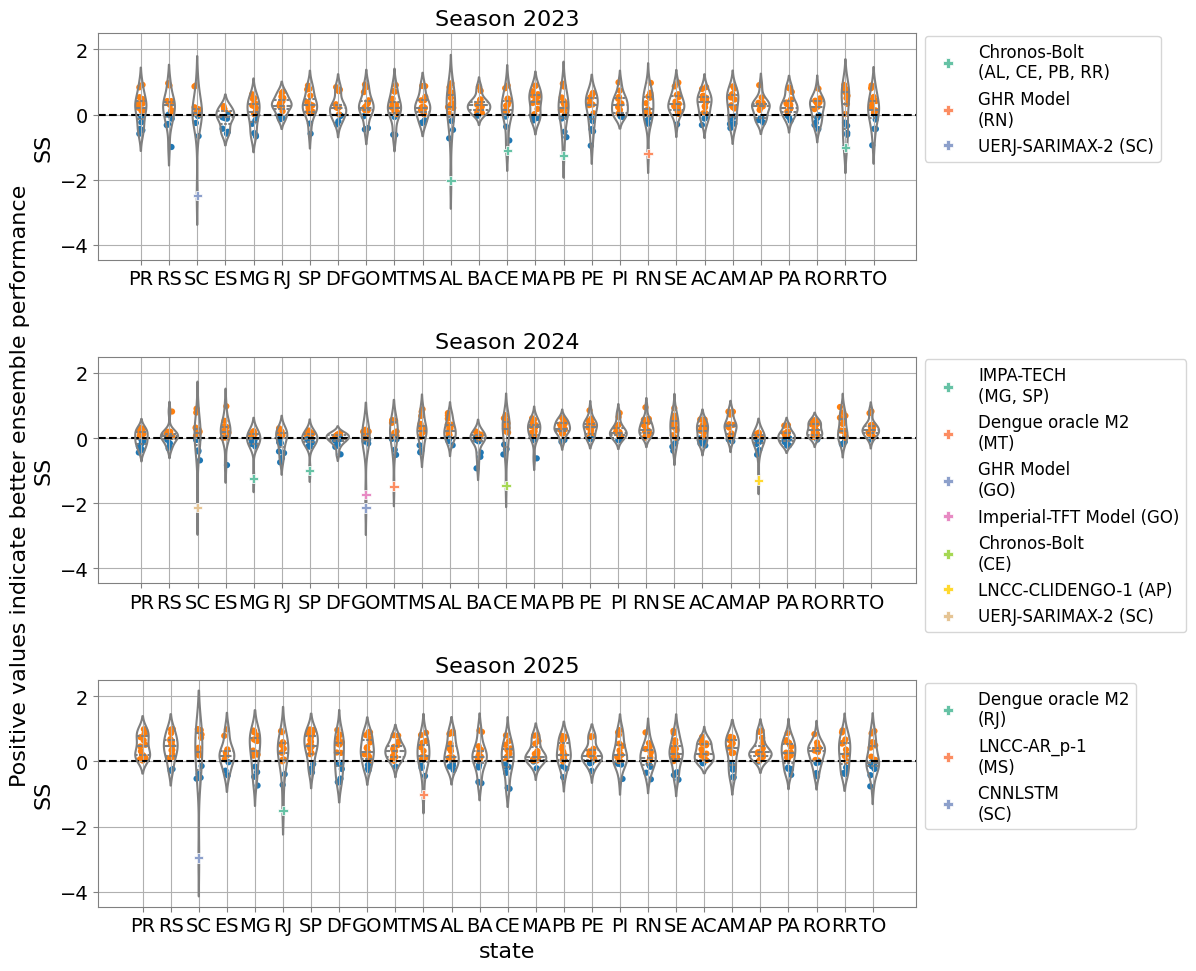

In [22]:
plt.rcParams['legend.fontsize'] = 12
_,ax = plt.subplots(3,1, figsize= (12,10), sharey = True)

sns.stripplot(ax=ax[0], x='state', y = 'SS', 
              data = df_ssm1.loc[df_ssm1.SS >= -1],size = 4.5,  hue = 'above_zero', zorder = 0, legend = False, )

sns.violinplot(ax=ax[0], x='state', y = 'SS', 
              data = df_ssm1, color = 'tab:grey',
              split=False, inner="quart", fill=False, zorder = 4)

sns.scatterplot(ax=ax[0], data= df_ssm1.loc[df_ssm1.SS < -1],
                x = 'state', y = 'SS', hue = 'model_ref',palette='Set2', s=45,legend = True,
                marker = 'P', 
                 zorder = 20)

ax[0].set_title('Season 2023',fontsize =16)

sns.stripplot(ax=ax[1], x='state', y = 'SS', 
              data = df_ssm2.loc[df_ssm2.SS >= -1],size = 4.5,  hue = 'above_zero', zorder = 0, legend = False, )

sns.violinplot(ax=ax[1], x='state', y = 'SS', 
              data = df_ssm2, color = 'tab:grey',
              split=False, inner="quart", fill=False, zorder = 4)

sns.scatterplot(ax=ax[1], data= df_ssm2.loc[df_ssm2.SS < -1],
                x = 'state', y = 'SS', hue = 'model_ref',palette='Set2', s=45,legend = True,
                marker = 'P', 
                 zorder = 20)

ax[1].set_title('Season 2024',fontsize =16)

sns.stripplot(ax=ax[2], x='state', y = 'SS', 
              data = df_ssm3.loc[df_ssm3.SS >= -1],size = 4.5,  hue = 'above_zero', zorder = 0, legend = False, )

sns.violinplot(ax=ax[2], x='state', y = 'SS', 
              data = df_ssm3, color = 'tab:grey',
              split=False, inner="quart", fill=False, zorder = 4)

sns.scatterplot(ax=ax[2], data= df_ssm3.loc[df_ssm3.SS < -1],
                x = 'state', y = 'SS', hue = 'model_ref',palette='Set2', s=45,legend = True,
                marker = 'P', 
                 zorder = 20)

ax[2].set_title('Season 2025', fontsize =16)

for ax_ in ax.ravel():
    ax_.grid()
    ax_.axhline(0, color = 'black', linestyle = '--')

ax[0].set_xlabel('')
ax[1].set_xlabel('')
    #ax_.axhline(0, color = 'black', linestyle = '--')

#plt.suptitle('SS of the ensemble median vs each individual model.\nPositive values indicate better ensemble performance.',
#             y = 1.1)

ax[0].legend(bbox_to_anchor = (1,1.025))
ax[1].legend(bbox_to_anchor = (1,1.025))
ax[2].legend(bbox_to_anchor = (1,1.025))

_.text(0.0, 0.5, 'Positive values indicate better ensemble performance', va='center', rotation='vertical', fontsize=16)
plt.tight_layout()

plt.savefig('figures/ss_vs_ind_model.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [23]:
print('Validation test 3:')
print('median:', np.median(df_ssm3.SS))
print('mean:', np.mean(df_ssm3.SS))

Validation test 3:
median: 0.26254811428811053
mean: 0.25336519495093335


## Ensemble using top models:

Use the best 10 models to generate the ensemble:

Get the best models in validation test 1 and 2 (mean) by state:

In [24]:
n_models = 5
best_models_v12 = {}

for state in df_m_norm.state.unique():

    best_models_v12[f'{state}'] = df_m_norm.loc[(df_m_norm.state == state) & 
            (df_m_norm.validation_test.isin([1, 2]))].groupby(['state', 'model'])[['WIS']].mean().reset_index().sort_values(by = 'WIS').model.values[:n_models]

best_models_v12['PA']

array([155, 156, 157, 108, 150])

Generate the ensemble: 

In [25]:
dfm_top = pd.DataFrame()

for st in df_preds.state.unique(): 
    df_median_ens = compute_ensemble(df_preds.loc[(df_preds.state == st) &
                                                  (df_preds.valid_test == '3') & 
                                                  (df_preds.model_id.isin(best_models_v12[st]))])
    df_median_ens.head()

    dfm_top = pd.concat([dfm_top, df_median_ens], ignore_index = True)

dfm_top['model_id'] = 'E_median_top'

dfm_top.head()

,date,state,valid_test,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id
0,2024-10-06,PA,3,35.959166,42.424022,60.000000,82.796904,119.110781,176.600818,263.767031,369.368872,429.000000,E_median_top
1,2024-10-13,PA,3,37.421617,44.808032,54.685446,87.000000,141.000000,210.000000,289.000000,375.925265,499.136317,E_median_top
2,2024-10-20,PA,3,35.627734,41.527597,52.545600,79.000000,131.000000,198.000000,297.068113,409.778907,501.573479,E_median_top
3,2024-10-27,PA,3,37.144459,43.541704,52.844471,88.000000,137.075982,214.489477,299.000000,363.012659,473.984550,E_median_top
4,2024-11-03,PA,3,39.060140,46.518267,56.000000,97.000000,156.000000,233.000000,322.000000,411.882197,558.393547,E_median_top


Compute the wis:

In [26]:
df_m_e_top = pd.DataFrame()

for state in dfm_top.state.unique():
    #print(f'{state} - {test_year}')
    df_preds_ = dfm_top.loc[(dfm_top.state == state)].sort_values(by='date')

    df_w = data.loc[(data.uf == state) & data.date.isin(df_preds_.date.unique())].reset_index(drop=True)

    scores =[]
    models_ids = df_preds_.model_id.unique()
    
    wis = compute_metrics('E_median_top', df_w, df_preds_)
        
    df_m_e_top = pd.concat([df_m_e_top,
                           pd.DataFrame([['E_top', state, '3', wis ]],
                            columns = ['model', 'state', 'validation_test', 'WIS'] 
                            )], ignore_index = True)

df_m_e_top.head()

,model,state,validation_test,WIS
0,E_top,PA,3,0.163430
1,E_top,SP,3,0.307242
2,E_top,RO,3,0.425385
3,E_top,RS,3,0.231805
4,E_top,RR,3,0.423389


In [27]:
df_m_merged_top = df_m_merged.merge(df_m_e_top, on = ['state', 'validation_test'], suffixes=('', '_ens_top'))
df_m_merged_top.head()

,best_model_norm,state,model,validation_test,WIS,model_ens,WIS_ens,SS,model_ens_top,WIS_ens_top
0,133,AC,133,3,0.283760,E_median_all,0.232481,0.180712,E_top,0.219360
1,135,AL,135,3,0.341129,E_median_all,0.429003,-0.257595,E_top,0.449325
2,144,AM,144,3,0.159181,E_median_all,0.234123,-0.470797,E_top,0.169980
3,108,AP,108,3,4.862754,E_median_all,0.249132,0.948767,E_top,0.286351
4,136,BA,136,3,0.257562,E_median_all,0.284538,-0.104737,E_top,0.315168


Compute the ss:

In [28]:
df_m_merged_top['SS'] = compute_ss(df_m_merged_top, col1 = 'WIS_ens_top', col_ref = 'WIS')
df_m_merged_top.head()

,best_model_norm,state,model,validation_test,WIS,model_ens,WIS_ens,SS,model_ens_top,WIS_ens_top
0,133,AC,133,3,0.283760,E_median_all,0.232481,0.226953,E_top,0.219360
1,135,AL,135,3,0.341129,E_median_all,0.429003,-0.317169,E_top,0.449325
2,144,AM,144,3,0.159181,E_median_all,0.234123,-0.067842,E_top,0.169980
3,108,AP,108,3,4.862754,E_median_all,0.249132,0.941113,E_top,0.286351
4,136,BA,136,3,0.257562,E_median_all,0.284538,-0.223661,E_top,0.315168


In [29]:
best_models_v12['AC']

array([133, 144, 143, 150, 135])

make the plot:

In [30]:
order = ['PR', 'SC', 'RS','SP', 'MG', 'RJ', 'ES', 
         'DF', 'MT', 'MS', 'GO', 'BA', 'CE', 'PE',
        'PB', 'PI', 'RN', 'MA', 'AL', 'SE',
         'RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO' ]


df_m_merged_top['state'] = pd.Categorical(df_m_merged_top['state'], 
                                          categories = order, 
                                          ordered = True)

df_m_merged_top = df_m_merged_top.sort_values(by = 'state')

df_m_merged_top.head()

,best_model_norm,state,model,validation_test,WIS,model_ens,WIS_ens,SS,model_ens_top,WIS_ens_top
17,157,PR,157,3,1.670130,E_median_all,0.219882,0.794267,E_top,0.343601
23,157,SC,157,3,6.874736,E_median_all,0.521595,0.714000,E_top,1.966178
22,156,RS,156,3,0.226001,E_median_all,0.289270,-0.025680,E_top,0.231805
25,156,SP,156,3,0.437049,E_median_all,0.234772,0.297009,E_top,0.307242
10,108,MG,108,3,5.077377,E_median_all,0.264353,0.877903,E_top,0.619933


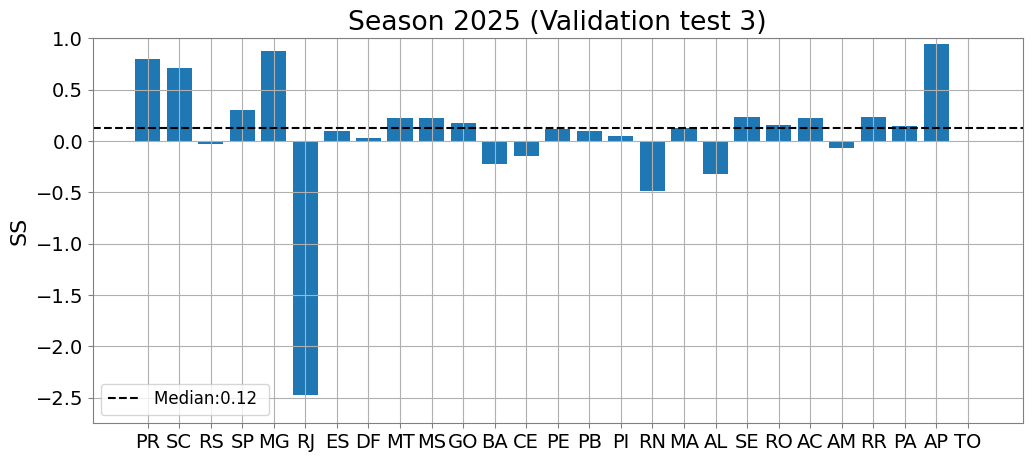

In [31]:
_,ax = plt.subplots(figsize = (12, 5))

ax.bar(df_m_merged_top.state, df_m_merged_top.SS)

ax.axhline(np.median(df_m_merged_top.SS), color = 'black', 
              linestyle = '--', label = f'Median:{np.round(np.median(df_m_merged_top.SS),2)} ')

ax.grid()
ax.legend()
ax.set_ybound([-2.75, 1])
ax.set_title('Season 2025 (Validation test 3)')
ax.set_ylabel('SS')
#ax.text(0.0, 0.5, 'Positive values indicate better ensemble performance', va='center', rotation='vertical', fontsize=16)

#ax.set_title('SS of the ensemble (with top 5 models) vs\nthe best model in validation test 1 and 2')
plt.savefig('figures/ens_top_5_vs_best_models.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Plot the SS for each individual model in validation test 3:

In [32]:
df_m_e_top.head()

,model,state,validation_test,WIS
0,E_top,PA,3,0.163430
1,E_top,SP,3,0.307242
2,E_top,RO,3,0.425385
3,E_top,RS,3,0.231805
4,E_top,RR,3,0.423389


In [33]:
df_m_norm.head()

,model,state,validation_test,WIS
0,108,PA,1,0.306515
1,158,PA,1,0.235720
2,133,PA,1,0.178181
3,144,PA,1,0.162322
4,152,PA,1,0.628968


In [34]:
df_ss_median_all = pd.DataFrame()

for state in df_m_norm.state.unique():
    
    dfm = df_m_norm.loc[(df_m_norm.state == state ) & (df_m_norm.validation_test == 3)]

    dfm_e = df_m_e_top.loc[(df_m_e_top.state == state) & (df_m_e_top.validation_test == '3')]
    
    for model in dfm.model.unique(): 

        ss =  1- (dfm_e.WIS.values[0]/dfm.loc[dfm.model == model].WIS.values[0])

        df_ss_median_all = pd.concat([df_ss_median_all,
                           pd.DataFrame([[state, model, ss ]],
                            columns = ['state', 'model_ref', 'SS'] 
                            )], ignore_index = True)

df_ss_median_all.head()

,state,model_ref,SS
0,PA,108,0.637265
1,PA,158,0.348451
2,PA,133,0.369266
3,PA,144,0.473402
4,PA,152,0.749628


In [35]:
print('Validation test 3:')
print('median:', np.median(df_ss_median_all.SS))
print('mean:', np.mean(df_ss_median_all.SS))

Validation test 3:
median: 0.23760158278035437
mean: 0.1347998725744654


In [36]:
df_ss_median_all['above_zero'] = True
df_ss_median_all.loc[df_ss_median_all.SS <= 0, 'above_zero'] = False

df_ss_median_all.head()

,state,model_ref,SS,above_zero
0,PA,108,0.637265,True
1,PA,158,0.348451,True
2,PA,133,0.369266,True
3,PA,144,0.473402,True
4,PA,152,0.749628,True


In [37]:
dict_models_name = {157: 'UERJ-SARIMAX-2 (PI, MT)', 156: 'Dengue oracle M2\n(MG, RJ)', 155: 'Dengue Oracle M1\n(SC)', 135:'GHR Model (RJ, SC)', 
                    133:'Chronos-Bolt', 158: 'Cornell PEH (SC)', 143: 'Model fourier-\ngravidade (MG, SC)', 144:'Beat it \n(SC)', 
                    150: 'LNCC-AR_p-1\n(MG)', 
        145: 'CNNLSTM \n(MG, SC)' , 141: 'Kaust Geohealth', 136: 'Imperial-TFT Model (SC)', 137: 'LSTM-RF model', 
                    138: 'TSMixer ZKI-PH4', 154: 'LNCC-SURGE-1 (SC)', 152: 'LNCC-CLIDENGO-1 (SC)', 134: 'ISI_Dengue_Model', 
                    108:'IMPA-TECH'} 
df_ss_median_all['model_ref'] =  df_ss_median_all['model_ref'].replace(dict_models_name)


In [38]:
df_ss_median_all.loc[df_ss_median_all.SS < 0]

,state,model_ref,SS,above_zero
11,PA,"Dengue oracle M2\n(MG, RJ)",-0.017769,False
18,SP,Beat it \n(SC),-0.014228,False
22,SP,LNCC-AR_p-1\n(MG),-0.408741,False
27,SP,"GHR Model (RJ, SC)",-0.747397,False
29,SP,Dengue Oracle M1\n(SC),-0.592362,False
...,...,...,...,...
384,TO,Imperial-TFT Model (SC),-0.322161,False
385,TO,Dengue Oracle M1\n(SC),-0.143264,False
388,SE,Chronos-Bolt,-0.369379,False
393,SE,LNCC-AR_p-1\n(MG),-0.247527,False


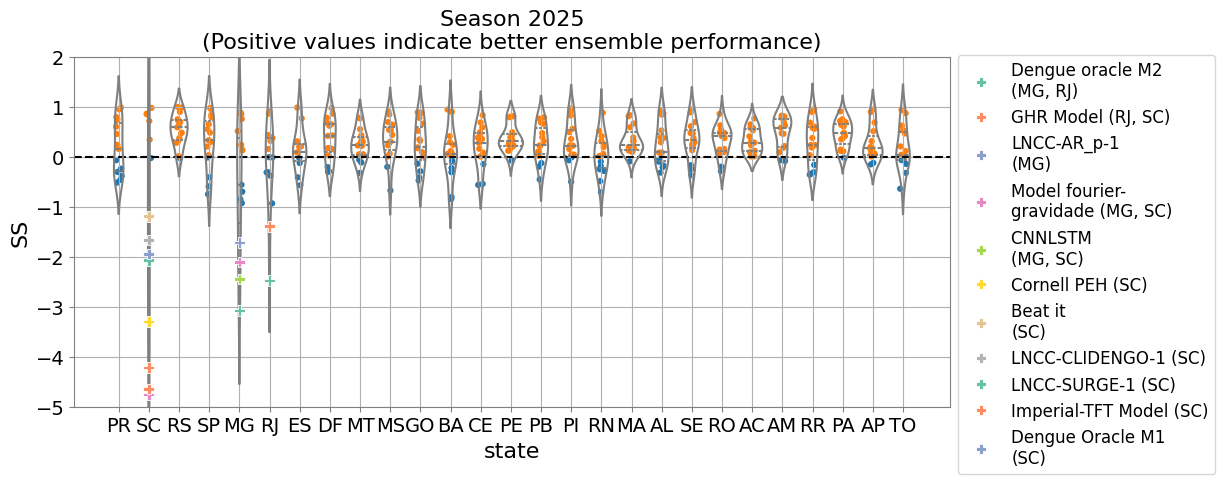

In [39]:
plt.rcParams['legend.fontsize'] = 12

df_ss_median_all['state'] = pd.Categorical(df_ss_median_all['state'],
                                     categories = order,
                                     ordered = True)

_,ax = plt.subplots(figsize= (10,5))

sns.stripplot(ax=ax, x='state', y = 'SS', 
              data = df_ss_median_all.loc[df_ss_median_all.SS >= -1],size = 4.5,  hue= 'above_zero', zorder = 0, legend = False, )

sns.violinplot(ax=ax, x='state', y = 'SS', 
              data = df_ss_median_all, color = 'tab:grey',
              split=False, inner="quart", fill=False, zorder = 4)

gfg = sns.scatterplot(ax=ax, data= df_ss_median_all.loc[df_ss_median_all.SS < -1],
                x = 'state', y = 'SS', hue = 'model_ref',palette='Set2', s=60,legend = True,
                marker = 'P', 
                 zorder = 20)

gfg.legend(fontsize=5)
ax.set_title('Season 2025\n(Positive values indicate better ensemble performance)', 
             fontsize =16)

ax.grid()
ax.axhline(0, color = 'black', linestyle = '--')
#ax.axhline(-0.5, color = 'blue', linestyle = '--')

plt.tight_layout()

#plt.suptitle('SS of the ensemble median vs each individual model.\nPositive values indicate better ensemble performance.',
#             y = 1.1)
ax.set_ybound([-5,2])
ax.legend(bbox_to_anchor = (1,1.03))
plt.savefig('figures/ss_vs_ind_model_top5.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [40]:
df_ss_median_all.loc[df_ss_median_all.SS <= -1]

,state,model_ref,SS,above_zero
86,RJ,"Dengue oracle M2\n(MG, RJ)",-2.474266,False
87,RJ,"GHR Model (RJ, SC)",-1.387286,False
172,MG,LNCC-AR_p-1\n(MG),-1.717019,False
173,MG,"Model fourier-\ngravidade (MG, SC)",-2.105813,False
175,MG,"CNNLSTM \n(MG, SC)",-2.442063,False
176,MG,"Dengue oracle M2\n(MG, RJ)",-3.075245,False
357,SC,Cornell PEH (SC),-3.294543,False
359,SC,Beat it \n(SC),-1.187030,False
360,SC,LNCC-CLIDENGO-1 (SC),-1.662653,False
364,SC,"Model fourier-\ngravidade (MG, SC)",-4.754370,False


Improvement of the SS as the number of ensemble members increases

In [41]:

median_ss_top = {}
mean_ss_top = {}
median_ss_top_all = {}
mean_ss_top_all = {}

for n in np.arange(1, 16): 
    #print(n) 
    n_models = n
    best_models_v12 = {}

    for state in df_m_norm.state.unique():

        # get best models
        best_models_v12[f'{state}'] = df_m_norm.loc[(df_m_norm.state == state) & 
                (df_m_norm.validation_test.isin([1, 2]))].groupby(['state', 'model'])[['WIS']].mean().reset_index().sort_values(by = 'WIS').model.values[:n_models]
        
    #print(len(best_models_v12['CE']))
    # get ensemble 
    dfm_top = pd.DataFrame()

    for st in df_preds.state.unique(): 
        df_median_ens = compute_ensemble(df_preds.loc[(df_preds.state == st) &
                                                        (df_preds.valid_test == '3') & 
                                                        (df_preds.model_id.isin(best_models_v12[st]))])
        df_median_ens.head()

        dfm_top = pd.concat([dfm_top, df_median_ens], ignore_index = True)

        dfm_top['model_id'] = 'E_median_top'

    # get wis 
    df_m_e_top = pd.DataFrame()

    for state in dfm_top.state.unique():
            #print(f'{state} - {test_year}')
        df_preds_ = dfm_top.loc[(dfm_top.state == state)].sort_values(by='date')

        df_w = data.loc[(data.uf == state) & data.date.isin(df_preds_.date.unique())].reset_index(drop=True)

        scores =[]
        models_ids = df_preds_.model_id.unique()
            
        wis = compute_metrics('E_median_top', df_w, df_preds_)
                
        df_m_e_top = pd.concat([df_m_e_top,
                                pd.DataFrame([['E_median_top', state, '3', wis ]],
                                    columns = ['model', 'state', 'validation_test', 'WIS'] 
                                    )], ignore_index = True)
                

    # agg with wis best models
    df_m_merged_top = df_m_merged.merge(df_m_e_top, on = ['state', 'validation_test'], suffixes=('', '_ens_top'))

    df_m_merged_top['SS'] = compute_ss(df_m_merged_top, col1 = 'WIS_ens_top', col_ref = 'WIS')

    # agg with wis best models
    df_ss_median = pd.DataFrame()

    for state in df_m_norm.state.unique():
        
        dfm = df_m_norm.loc[(df_m_norm.state == state ) & (df_m_norm.validation_test == 3)]

        dfm_e = df_m_e_top.loc[(df_m_e_top.state == state) & (df_m_e_top.validation_test == '3')]
        
        for model in dfm.model.unique(): 

            ss =  1- (dfm_e.WIS.values[0]/dfm.loc[dfm.model == model].WIS.values[0])

            df_ss_median = pd.concat([df_ss_median,
                            pd.DataFrame([[state, model, ss ]],
                                columns = ['state', 'model_ref', 'SS'] 
                                )], ignore_index = True)

    median_ss_top[n_models] = np.median(df_m_merged_top.SS) 
    mean_ss_top[n_models] = np.mean(df_m_merged_top.SS) 
    median_ss_top_all[n_models] = np.median(df_ss_median.SS) 
    mean_ss_top_all[n_models] = np.mean(df_ss_median.SS) 

    


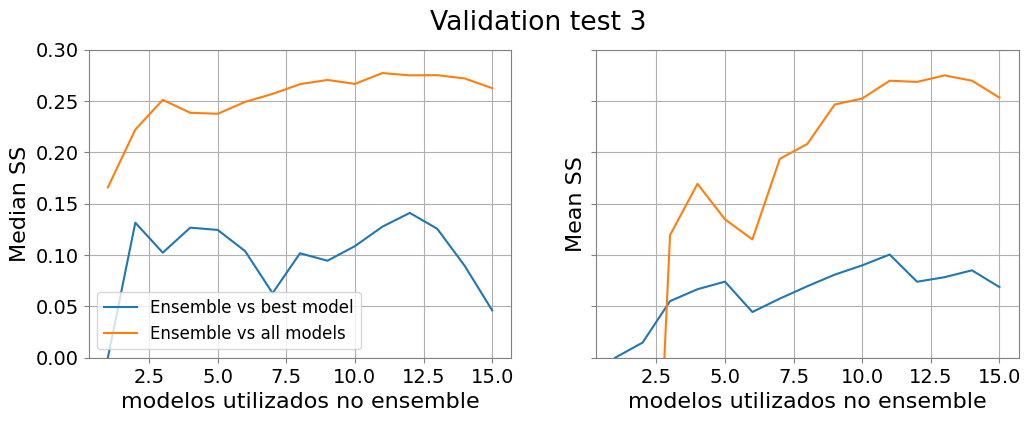

In [42]:
_,ax = plt.subplots(1,2, figsize = (12, 4), sharey = True, sharex = True)

ax[0].plot(median_ss_top.keys(), median_ss_top.values(), label = 'Ensemble vs best model')

ax[0].plot(median_ss_top_all.keys(), median_ss_top_all.values(), label = 'Ensemble vs all models')

ax[0].set_ylabel('Median SS')
#ax[0,0].set_xlabel('Top n models included in the ensemble')

ax[1].plot(mean_ss_top.keys(), mean_ss_top.values(), label = 'Ensemble vs best model')

ax[1].plot(mean_ss_top_all.keys(), mean_ss_top_all.values(), label = 'Ensemble vs all models')

ax[1].set_ylabel('Mean SS')
#ax[0,1].set_xlabel('Top n models included in the ensemble')

ax[0].set_ylim([0, 0.3])
#plt.suptitle('The top models were select based on the validation \n test 1 and 2 and evaluated in validation test 3',
#             y = 1.05)

ax[0].legend()

for ax_ in ax.ravel():

    ax_.grid()
    ax_.set_xlabel('modelos utilizados no ensemble')

plt.suptitle('Validation test 3')

plt.show()